In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Define paths for the Brain Tumors MRI Dataset
BASE_PATH = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/'
PROCESSED_IMAGES = f'{BASE_PATH}data/images_processed/'
ENHANCED_IMAGES = f'{BASE_PATH}data/images_enhanced/'
MAPPING_FILE = f'{BASE_PATH}data/mapping.csv'
NOTES_DIR = f'{BASE_PATH}data/ehr_notes_processed/'
NOTEBOOKS_DIR = f'{BASE_PATH}notebooks/'

# Create directories if they don't exist
import os
for directory in [PROCESSED_IMAGES, ENHANCED_IMAGES, NOTES_DIR, NOTEBOOKS_DIR]:
    os.makedirs(directory, exist_ok=True)

# Print paths for verification
print("Paths set:")
print(f"Base Path: {BASE_PATH}")
print(f"Processed Images: {PROCESSED_IMAGES}")
print(f"Enhanced Images: {ENHANCED_IMAGES}")
print(f"Mapping File: {MAPPING_FILE}")
print(f"EHR Notes: {NOTES_DIR}")
print(f"Notebooks: {NOTEBOOKS_DIR}")

Paths set:
Base Path: /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/
Processed Images: /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_processed/
Enhanced Images: /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_enhanced/
Mapping File: /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/mapping.csv
EHR Notes: /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/ehr_notes_processed/
Notebooks: /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/notebooks/


In [ ]:
import pandas as pd
import os
from google.colab import drive

# Set paths (same as project)
BASE_PATH = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/'
PROCESSED_IMAGES = BASE_PATH + 'data/images_processed/'
ENHANCED_IMAGES = BASE_PATH + 'data/images_enhanced/'
MAPPING_FILE = BASE_PATH + 'data/mapping.csv'
NOTES_DIR = BASE_PATH + 'data/ehr_notes_processed/'
NOTEBOOKS_DIR = BASE_PATH + 'notebooks/'

# Mount Google Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Load mapping.csv
try:
    mapping = pd.read_csv(MAPPING_FILE)
    print(f"Loaded {len(mapping)} images from mapping.csv")
except:
    print(f"Error: Can't find {MAPPING_FILE}. Check Milestone 1.")
    exit()

# Check required columns
must_have = ['file_id', 'image_path', 'note_path', 'diagnosis', 'icd10', 'modality', 'enhanced_image_path']
if 'patient_name' in mapping:
    must_have.append('patient_name')
elif 'patient_id' in mapping:
    must_have.append('patient_id')

missing = [col for col in must_have if col not in mapping]
if missing:
    print(f"Missing columns: {missing}")
    # Add patient_name if missing
    if 'patient_name' not in mapping:
        if 'patient_id' in mapping:
            mapping['patient_name'] = mapping['patient_id'].apply(lambda x: f"Patient_{x}")
            print("Made patient_name from patient_id")
        else:
            mapping['patient_name'] = [f"Patient_{i+1:03d}" for i in range(len(mapping))]
            print("Added fake patient_name (Patient_001, etc.)")
else:
    print("All needed columns found")

# Check if image files exist
bad_images = sum(1 for path in mapping['image_path'] if pd.notnull(path) and not os.path.exists(path))
bad_enhanced = sum(1 for path in mapping['enhanced_image_path'] if pd.notnull(path) and not os.path.exists(path))
print(f"Missing original images: {bad_images}")
print(f"Missing enhanced images: {bad_enhanced}")

# Show first 3 rows
show_cols = ['file_id', 'patient_name' if 'patient_name' in mapping else 'patient_id',
             'image_path', 'diagnosis', 'modality', 'enhanced_image_path']
show_cols = [col for col in show_cols if col in mapping]
print("\nFirst 3 images:")
mapping[show_cols].head(3)

Loaded 20000 images from mapping.csv
All needed columns found
Missing original images: 0
Missing enhanced images: 0

First 3 images:


,file_id,image_path,diagnosis,modality,enhanced_image_path
0,1,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,Normal,MRI,NaN
1,2,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,Normal,MRI,NaN
2,3,/content/drive/MyDrive/Enhancing_EHRs_with_Gen...,Normal,MRI,NaN


In [ ]:
import pandas as pd
import os
from google.colab import drive

# Define paths (consistent with previous setup)
BASE_PATH = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/'
PROCESSED_IMAGES = BASE_PATH + 'data/images_processed/'
ENHANCED_IMAGES = BASE_PATH + 'data/images_enhanced/'
MAPPING_FILE = BASE_PATH + 'data/mapping.csv'
NOTES_DIR = BASE_PATH + 'data/ehr_notes_processed/'
NOTEBOOKS_DIR = BASE_PATH + 'notebooks/'

# Mount Google Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Load mapping.csv
try:
    mapping = pd.read_csv(MAPPING_FILE)
    print(f"Loaded {len(mapping)} images from mapping.csv")
except FileNotFoundError:
    print(f"Error: Can't find {MAPPING_FILE}. Check Milestone 1.")
    exit()

# Update image_path (fix relative paths)
mapping['image_path'] = mapping['image_path'].apply(
    lambda x: x.replace('data/images_processed/', PROCESSED_IMAGES) if pd.notnull(x) and 'data/images_processed/' in x else x
)

# Update enhanced_image_path (fix relative paths)
if 'enhanced_image_path' in mapping.columns:
    mapping['enhanced_image_path'] = mapping['enhanced_image_path'].apply(
        lambda x: x.replace('data/images_enhanced/', ENHANCED_IMAGES) if pd.notnull(x) and 'data/images_enhanced/' in x else x
    )
else:
    print("Warning: enhanced_image_path column missing; run Step 3 to add it")

# Check missing files for image_path
missing_images = 0
print("\nChecking image_path:")
for path in mapping['image_path']:
    if pd.notnull(path) and not os.path.exists(path):
        missing_images += 1
        if missing_images <= 3:
            print(f"Missing original: {path}")

# Check missing files for enhanced_image_path
missing_enhanced = 0
if 'enhanced_image_path' in mapping.columns:
    print("\nChecking enhanced_image_path:")
    for path in mapping['enhanced_image_path']:
        if pd.notnull(path) and not os.path.exists(path):
            missing_enhanced += 1
            if missing_enhanced <= 3:
                print(f"Missing enhanced: {path}")
else:
    missing_enhanced = len(mapping)  # All missing if column absent

# Save updated mapping.csv
mapping.to_csv(MAPPING_FILE, index=False)
print(f"\nUpdated {MAPPING_FILE} with corrected paths")

# Print summary
print(f"\nTotal images: {len(mapping)}")
print(f"Missing original images: {missing_images}")
print(f"Missing enhanced images: {missing_enhanced}")

Loaded 20000 images from mapping.csv

Checking image_path:
Missing original: /content/drive/MyDrive/Enhancing_EHRs_with_GenAI//content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_processed/Normal/N_1.png
Missing original: /content/drive/MyDrive/Enhancing_EHRs_with_GenAI//content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_processed/Normal/N_10.png
Missing original: /content/drive/MyDrive/Enhancing_EHRs_with_GenAI//content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_processed/Normal/N_100.png

Checking enhanced_image_path:
Missing enhanced: /content/drive/MyDrive/Enhancing_EHRs_with_GenAI//content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_enhanced/enhanced_1115.png
Missing enhanced: /content/drive/MyDrive/Enhancing_EHRs_with_GenAI//content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_enhanced/enhanced_2042.png
Missing enhanced: /content/drive/MyDrive/Enhancing_EHRs_with_GenAI//content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_enhanced/e

In [ ]:
import pandas as pd
import os
from google.colab import drive

# Define paths (consistent with previous setup)
BASE_PATH = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/'
PROCESSED_IMAGES = BASE_PATH + 'data/images_processed/'
ENHANCED_IMAGES = BASE_PATH + 'data/images_enhanced/'
MAPPING_FILE = BASE_PATH + 'data/mapping.csv'
NOTES_DIR = BASE_PATH + 'data/ehr_notes_processed/'
NOTEBOOKS_DIR = BASE_PATH + 'notebooks/'

# Mount Google Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Load mapping.csv
try:
    mapping = pd.read_csv(MAPPING_FILE)
    print(f"Loaded {len(mapping)} images from mapping.csv")
except FileNotFoundError:
    print(f"Error: Can't find {MAPPING_FILE}. Check Milestone 1.")
    exit()

# Update modality column
if 'modality' not in mapping.columns or mapping['modality'].isnull().any():
    mapping['modality'] = 'Brain Tumor MRI'
    print("Added/Updated modality to 'Brain Tumor MRI'")
else:
    print("Modality column already exists and is valid")

# Save to original mapping.csv (overwrite)
mapping.to_csv(MAPPING_FILE, index=False)
print(f"Saved: {MAPPING_FILE}")

Loaded 20000 images from mapping.csv
Modality column already exists and is valid
Saved: /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/mapping.csv


In [ ]:
import pandas as pd
import os
from PIL import Image
from google.colab import drive

# Define paths (consistent with previous setup)
BASE_PATH = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/'
PROCESSED_IMAGES = BASE_PATH + 'data/images_processed/'
ENHANCED_IMAGES = BASE_PATH + 'data/images_enhanced/'
MAPPING_FILE = BASE_PATH + 'data/mapping.csv'
NOTES_DIR = BASE_PATH + 'data/ehr_notes_processed/'
NOTEBOOKS_DIR = BASE_PATH + 'notebooks/'

# Mount Google Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Load mapping.csv
try:
    mapping = pd.read_csv(MAPPING_FILE)
    print(f"Loaded {len(mapping)} images from mapping.csv")
except FileNotFoundError:
    print(f"Error: Can't find {MAPPING_FILE}. Check Milestone 1.")
    exit()

# Check image sizes
print("\nChecking original images (should be 256x256)...")
size_issues_original = 0
for idx, row in mapping.head(10).iterrows():  # Check first 10
    img_path = row['image_path']
    fid = row['file_id']
    patient = row.get('patient_name', row.get('patient_id', f'Unknown_{fid}'))
    if pd.notnull(img_path) and os.path.exists(img_path):
        try:
            with Image.open(img_path) as img:
                w, h = img.size
                if w != 256 or h != 256:
                    print(f"  Issue: {img_path} (File ID: {fid}, Patient: {patient}) → {w}x{h}")
                    size_issues_original += 1
        except Exception as e:
            print(f"  Error reading {img_path} (File ID: {fid}, Patient: {patient}): {e}")
            size_issues_original += 1
    else:
        print(f"  Missing: {img_path} (File ID: {fid}, Patient: {patient})")

print("\nChecking enhanced images (should be 512x512)...")
size_issues_enhanced = 0
if 'enhanced_image_path' in mapping.columns:
    for idx, row in mapping[mapping['enhanced_image_path'].notnull()].head(10).iterrows():  # Check first 10 enhanced
        enh_path = row['enhanced_image_path']
        fid = row['file_id']
        patient = row.get('patient_name', row.get('patient_id', f'Unknown_{fid}'))
        if pd.notnull(enh_path) and os.path.exists(enh_path):
            try:
                with Image.open(enh_path) as img:
                    w, h = img.size
                    if w != 512 or h != 512:
                        print(f"  Issue: {enh_path} (File ID: {fid}, Patient: {patient}) → {w}x{h}")
                        size_issues_enhanced += 1
            except Exception as e:
                print(f"  Error reading {enh_path} (File ID: {fid}, Patient: {patient}): {e}")
                size_issues_enhanced += 1
        else:
            print(f"  Missing: {enh_path} (File ID: {fid}, Patient: {patient})")
else:
    print("Warning: enhanced_image_path column missing; run Step 3 to add it")

# Print summary
if size_issues_original == 0:
    print("\nAll checked original images are 256x256")
else:
    print(f"\n{size_issues_original} original images have wrong size!")
if size_issues_enhanced == 0 and 'enhanced_image_path' in mapping.columns:
    print("All checked enhanced images are 512x512")
else:
    print(f"{size_issues_enhanced} enhanced images have wrong size or errors!")

Loaded 20000 images from mapping.csv

Checking original images (should be 256x256)...
  Missing: /content/drive/MyDrive/Enhancing_EHRs_with_GenAI//content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_processed/Normal/N_1.png (File ID: 1, Patient: Unknown_1)
  Missing: /content/drive/MyDrive/Enhancing_EHRs_with_GenAI//content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_processed/Normal/N_10.png (File ID: 2, Patient: Unknown_2)
  Missing: /content/drive/MyDrive/Enhancing_EHRs_with_GenAI//content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_processed/Normal/N_100.png (File ID: 3, Patient: Unknown_3)
  Missing: /content/drive/MyDrive/Enhancing_EHRs_with_GenAI//content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_processed/Normal/N_100_BR_.png (File ID: 4, Patient: Unknown_4)
  Missing: /content/drive/MyDrive/Enhancing_EHRs_with_GenAI//content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_processed/Normal/N_100_DA_.png (File ID: 5, Patient: Unknown_5)
  Mi

In [ ]:
import os
from google.colab import drive

# Define paths (consistent with project)
BASE_PATH = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/'
MAPPING_FILE = BASE_PATH + 'data/mapping.csv'
PROCESSED_IMAGES = BASE_PATH + 'data/images_processed/'
ENHANCED_IMAGES = BASE_PATH + 'data/images_enhanced/'
NOTES_DIR = BASE_PATH + 'data/ehr_notes_processed/'
NOTEBOOKS_DIR = BASE_PATH + 'notebooks/'

# Create directories if they don't exist
for directory in [PROCESSED_IMAGES, ENHANCED_IMAGES, NOTES_DIR, NOTEBOOKS_DIR]:
    os.makedirs(directory, exist_ok=True)

# Print paths to confirm
print("Paths set:")
print(f"Base Path: {BASE_PATH}")
print(f"Mapping File: {MAPPING_FILE}")
print(f"Processed Images: {PROCESSED_IMAGES}")
print(f"Enhanced Images: {ENHANCED_IMAGES}")
print(f"EHR Notes: {NOTES_DIR}")
print(f"Notebooks: {NOTEBOOKS_DIR}")

Paths set:
Base Path: /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/
Mapping File: /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/mapping.csv
Processed Images: /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_processed/
Enhanced Images: /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_enhanced/
EHR Notes: /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/ehr_notes_processed/
Notebooks: /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/notebooks/


In [ ]:
!pip install realesrgan==0.3.0 --no-deps -q
!pip install opencv-python pillow numpy tqdm -q

In [ ]:
%cd /content
!mkdir -p ESRGAN/models
!pwd

# Download RealESRGAN_x4plus.pth
!wget --no-check-certificate -O ESRGAN/models/RealESRGAN_x4plus.pth \
    https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth

# Download network_rrdbnet.py (correct URL)
!wget -O ESRGAN/models/network_rrdbnet.py \
    https://raw.githubusercontent.com/xinntao/ESRGAN/master/models/RRDBNet_arch.py

# List models directory
!ls -lh ESRGAN/models/

import pandas as pd
import os
import torch
import numpy as np
from PIL import Image
import cv2
from google.colab import drive

# Define paths
BASE_PATH = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/'
MAPPING_FILE = BASE_PATH + 'data/mapping.csv'
PROCESSED_IMAGES = BASE_PATH + 'data/images_processed/'
ENHANCED_IMAGES = BASE_PATH + 'data/images_enhanced/'
NOTES_DIR = BASE_PATH + 'data/ehr_notes_processed/'
NOTEBOOKS_DIR = BASE_PATH + 'notebooks/'
ESRGAN_DIR = '/content/ESRGAN/'
MODEL_PATH = f'{ESRGAN_DIR}models/RealESRGAN_x4plus.pth'

# Mount Google Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Create directories
for directory in [PROCESSED_IMAGES, ENHANCED_IMAGES, NOTES_DIR, NOTEBOOKS_DIR, f'{ESRGAN_DIR}models']:
    os.makedirs(directory, exist_ok=True)

# Load mapping.csv
try:
    mapping = pd.read_csv(MAPPING_FILE)
    print(f"Loaded {len(mapping)} images from mapping.csv")
except FileNotFoundError:
    print(f"Error: Can't find {MAPPING_FILE}. Check Milestone 1.")
    exit()

# Sample 15 images
sample = mapping.sample(15, random_state=42).reset_index(drop=True)
sample_paths = sample['image_path'].tolist()
sample_fids = sample['file_id'].tolist()

# Clean sample_paths (fix repeated prefix, preserve subfolder structure)
sample_paths = [
    path.replace(f"{BASE_PATH}{BASE_PATH}", BASE_PATH) if pd.notnull(path) else path
    for path in sample_paths
]

# Try ESRGAN enhancement
try:
    # Add ESRGAN to sys.path
    import sys
    sys.path.append(f'{ESRGAN_DIR}models')
    from network_rrdbnet import RRDBNet

    # Initialize device and model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = RRDBNet(num_in_ch=3, num_out_ch=3, num_feat=64, num_block=23, num_grow_ch=32)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device)['params'], strict=False)
    model.eval()
    model = model.to(device)
    print("ESRGAN model loaded successfully")

    # ESRGAN enhancement
    print("\nEnhancing images with ESRGAN...")
    enhanced_paths = []
    success_count = 0
    for i, (fid, img_path) in enumerate(zip(sample_fids, sample_paths), 1):
        dst_path = f"{ENHANCED_IMAGES}enhanced_{fid}.png"
        if not os.path.exists(img_path):
            print(f"{i}/15 → Missing: {img_path}")
            enhanced_paths.append("")
            continue

        try:
            img = Image.open(img_path).convert('RGB')
            img_tensor = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0
            img_tensor = img_tensor.unsqueeze(0).to(device)

            with torch.no-grad():
                output = model(img_tensor)

            output = output.squeeze().cpu().clamp(0, 1).permute(1, 2, 0).numpy() * 255.0
            enhanced_img = Image.fromarray(output.astype(np.uint8))
            enhanced_img = enhanced_img.resize((512, 512), Image.LANCZOS)  # Resize to 512x512
            enhanced_img.save(dst_path)

            # Verify saved image
            saved_img = cv2.imread(dst_path)
            if saved_img is None or saved_img.size == 0 or np.mean(saved_img) < 1:
                print(f"{i}/15 → Saved image is blank: {dst_path}")
                enhanced_paths.append("")
                continue

            print(f"{i}/15 → Enhanced: {dst_path}")
            enhanced_paths.append(dst_path)
            success_count += 1
        except Exception as e:
            print(f"{i}/15 → Error with {img_path}: {e}")
            enhanced_paths.append("")

except Exception as e:
    print(f"ESRGAN failed: {e}. Falling back to OpenCV pipeline...")

    # OpenCV enhancement
    print("\nEnhancing images with OpenCV...")
    enhanced_paths = []
    success_count = 0
    for i, (fid, img_path) in enumerate(zip(sample_fids, sample_paths), 1):
        dst_path = f"{ENHANCED_IMAGES}enhanced_{fid}.png"
        if not os.path.exists(img_path):
            print(f"{i}/15 → Missing: {img_path}")
            enhanced_paths.append("")
            continue

        try:
            img = cv2.imread(img_path, cv2.IMREAD_COLOR)
            if img is None or img.size == 0 or np.mean(img) < 1:
                print(f"{i}/15 → Cannot read or blank: {img_path}")
                enhanced_paths.append("")
                continue

            denoised = cv2.fastNlMeansDenoisingColored(
                img, None, h=10, hColor=10, templateWindowSize=7, searchWindowSize=21
            )
            up = cv2.resize(denoised, (512, 512), interpolation=cv2.INTER_CUBIC)
            gauss = cv2.GaussianBlur(up, (0, 0), 2.0)
            sharp = cv2.addWeighted(up, 1.5, gauss, -0.5, 0)

            success = cv2.imwrite(dst_path, sharp)
            if not success:
                print(f"{i}/15 → Failed to save: {dst_path}")
                enhanced_paths.append("")
                continue

            saved_img = cv2.imread(dst_path)
            if saved_img is None or saved_img.size == 0 or np.mean(saved_img) < 1:
                print(f"{i}/15 → Saved image is blank: {dst_path}")
                enhanced_paths.append("")
                continue

            print(f"{i}/15 → Enhanced: {dst_path}")
            enhanced_paths.append(dst_path)
            success_count += 1
        except Exception as e:
            print(f"{i}/15 → Error with {img_path}: {e}")
            enhanced_paths.append("")

# Update mapping.csv
if success_count > 0:
    sample['enhanced_image_path'] = enhanced_paths
    if 'enhanced_image_path' in mapping.columns:
        mapping = mapping.drop(columns=['enhanced_image_path'])
    mapping = mapping.merge(sample[['file_id', 'enhanced_image_path']], on='file_id', how='left')
    mapping.to_csv(MAPPING_FILE, index=False)
    print(f"Updated {MAPPING_FILE} with enhanced_image_path")
else:
    print("No images enhanced. Skipping mapping.csv update.")

/content
/content
--2025-11-12 13:52:36--  https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/387326890/08f0e941-ebb7-48f0-9d6a-73e87b710e7e?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-11-12T14%3A50%3A05Z&rscd=attachment%3B+filename%3DRealESRGAN_x4plus.pth&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-11-12T13%3A49%3A44Z&ske=2025-11-12T14%3A50%3A05Z&sks=b&skv=2018-11-09&sig=4h2WgkTcwZZx6QBBsLz3P3uNRWjai0j8form%2BTnIAiQ%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc2Mjk1NzM1NiwibmJmIjoxNzYyOTU1NTU2LCJwYXRoIjoicm

In [ ]:
import os
from google.colab import drive

# Define project paths (consistent with previous setup)
BASE_PATH = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/'
MAPPING_FILE = BASE_PATH + 'data/mapping.csv'
PROCESSED_IMAGES = BASE_PATH + 'data/images_processed/'
ENHANCED_IMAGES = BASE_PATH + 'data/images_enhanced/'
NOTES_DIR = BASE_PATH + 'data/ehr_notes_processed/'
NOTEBOOKS_DIR = BASE_PATH + 'notebooks/'

# Mount Google Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Set up ESRGAN directory
ESRGAN_DIR = '/content/ESRGAN'
if not os.path.exists(ESRGAN_DIR):
    print("Cloning Real-ESRGAN repository...")
    !git clone https://github.com/xinntao/Real-ESRGAN.git {ESRGAN_DIR}
%cd {ESRGAN_DIR}
!pwd

# Install dependencies
print("Installing dependencies...")
!pip install torch torchvision opencv-python pillow numpy

# Create models directory
!mkdir -p models

# Save RRDBNet architecture to models/network_rrdbnet.py
MODEL_CODE = """
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualDenseBlock(nn.Module):
    def __init__(self, nf=64, gc=32):
        super().__init__()
        self.conv1 = nn.Conv2d(nf, gc, 3, 1, 1, bias=True)
        self.conv2 = nn.Conv2d(nf + gc, gc, 3, 1, 1, bias=True)
        self.conv3 = nn.Conv2d(nf + 2 * gc, gc, 3, 1, 1, bias=True)
        self.conv4 = nn.Conv2d(nf + 3 * gc, gc, 3, 1, 1, bias=True)
        self.conv5 = nn.Conv2d(nf + 4 * gc, nf, 3, 1, 1, bias=True)
        self.lrelu = nn.LeakyReLU(negative_slope=0.2, inplace=True)

    def forward(self, x):
        x1 = self.lrelu(self.conv1(x))
        x2 = self.lrelu(self.conv2(torch.cat((x, x1), 1)))
        x3 = self.lrelu(self.conv3(torch.cat((x, x1, x2), 1)))
        x4 = self.lrelu(self.conv4(torch.cat((x, x1, x2, x3), 1)))
        x5 = self.conv5(torch.cat((x, x1, x2, x3, x4), 1))
        return x5 * 0.2 + x

class RRDB(nn.Module):
    def __init__(self, nf):
        super().__init__()
        self.rdb1 = ResidualDenseBlock(nf)
        self.rdb2 = ResidualDenseBlock(nf)
        self.rdb3 = ResidualDenseBlock(nf)

    def forward(self, x):
        out = self.rdb1(x)
        out = self.rdb2(out)
        out = self.rdb3(out)
        return out * 0.2 + x

class RRDBNet(nn.Module):
    def __init__(self, num_in_ch=3, num_out_ch=3, num_feat=64, num_block=23, num_grow_ch=32, scale=2):
        super().__init__()
        self.scale = scale
        self.conv_first = nn.Conv2d(num_in_ch, num_feat, 3, 1, 1)
        self.body = nn.Sequential(*[RRDB(num_feat) for _ in range(num_block)])
        self.conv_body = nn.Conv2d(num_feat, num_feat, 3, 1, 1)
        self.conv_up1 = nn.Conv2d(num_feat, num_feat, 3, 1, 1)
        self.conv_hr = nn.Conv2d(num_feat, num_feat, 3, 1, 1)
        self.conv_last = nn.Conv2d(num_feat, num_out_ch, 3, 1, 1)
        self.lrelu = nn.LeakyReLU(negative_slope=0.2, inplace=True)

    def forward(self, x):
        feat = self.conv_first(x)
        body_feat = self.conv_body(self.body(feat))
        feat = feat + body_feat
        feat = self.lrelu(self.conv_up1(F.interpolate(feat, scale_factor=self.scale, mode='nearest')))
        feat = self.lrelu(self.conv_hr(feat))
        out = self.conv_last(feat)
        return out
"""

with open('models/network_rrdbnet.py', 'w') as f:
    f.write(MODEL_CODE)
print("Saved RRDBNet architecture to models/network_rrdbnet.py")

# Verify file
!ls -lh models/network_rrdbnet.py

/content/ESRGAN
/content/ESRGAN
Installing dependencies...
Saved RRDBNet architecture to models/network_rrdbnet.py
-rw-r--r-- 1 root root 2.3K Nov 12 13:52 models/network_rrdbnet.py


In [ ]:
import pandas as pd
import os
import cv2
import numpy as np
from PIL import Image
from google.colab import drive

# Define paths (consistent with project)
BASE_PATH = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/'
MAPPING_FILE = BASE_PATH + 'data/mapping.csv'
PROCESSED_IMAGES = BASE_PATH + 'data/images_processed/'
ENHANCED_IMAGES = BASE_PATH + 'data/images_enhanced/'
NOTES_DIR = BASE_PATH + 'data/ehr_notes_processed/'
NOTEBOOKS_DIR = BASE_PATH + 'notebooks/'

# Mount Google Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Create directories
for directory in [PROCESSED_IMAGES, ENHANCED_IMAGES, NOTES_DIR, NOTEBOOKS_DIR]:
    os.makedirs(directory, exist_ok=True)

# Load mapping.csv
try:
    mapping = pd.read_csv(MAPPING_FILE)
    print(f"Loaded {len(mapping)} images from mapping.csv")
except FileNotFoundError:
    print(f"Error: Can't find {MAPPING_FILE}. Check Milestone 1.")
    exit()

# Sample 15 images
sample = mapping.sample(15, random_state=42).reset_index(drop=True)
sample_paths = sample['image_path'].tolist()
sample_fids = sample['file_id'].tolist()

# Clean sample_paths to fix repeated prefix
sample_paths = [
    path.replace(f"{BASE_PATH}{BASE_PATH}", BASE_PATH) if pd.notnull(path) else path
    for path in sample_paths
]

# OpenCV enhancement pipeline
print("\nEnhancing images with OpenCV...")
enhanced_paths = []
success_count = 0
for i, (fid, img_path) in enumerate(zip(sample_fids, sample_paths), 1):
    dst_path = f"{ENHANCED_IMAGES}enhanced_{fid}.png"
    if not os.path.exists(img_path):
        print(f"{i}/15 → Missing: {img_path}")
        enhanced_paths.append("")
        continue

    try:
        # Read image
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        if img is None or img.size == 0 or np.mean(img) < 1:
            print(f"{i}/15 → Cannot read or blank: {img_path}")
            enhanced_paths.append("")
            continue

        # 1. Denoise
        denoised = cv2.fastNlMeansDenoisingColored(
            img, None, h=10, hColor=10, templateWindowSize=7, searchWindowSize=21
        )
        # 2. 2x Upscale to 512x512
        up = cv2.resize(denoised, (512, 512), interpolation=cv2.INTER_CUBIC)
        # 3. Sharpen
        gauss = cv2.GaussianBlur(up, (0, 0), 2.0)
        sharp = cv2.addWeighted(up, 1.5, gauss, -0.5, 0)

        # Save and verify
        success = cv2.imwrite(dst_path, sharp)
        if not success:
            print(f"{i}/15 → Failed to save: {dst_path}")
            enhanced_paths.append("")
            continue

        saved_img = cv2.imread(dst_path)
        if saved_img is None or saved_img.size == 0 or np.mean(saved_img) < 1:
            print(f"{i}/15 → Saved image is blank: {dst_path}")
            enhanced_paths.append("")
            continue

        print(f"{i}/15 → Enhanced: {dst_path}")
        enhanced_paths.append(dst_path)
        success_count += 1
    except Exception as e:
        print(f"{i}/15 → Error with {img_path}: {e}")
        enhanced_paths.append("")

# Update mapping.csv only if enhancements succeeded
if success_count > 0:
    sample['enhanced_image_path'] = enhanced_paths
    if 'enhanced_image_path' in mapping.columns:
        mapping = mapping.drop(columns=['enhanced_image_path'])
    mapping = mapping.merge(sample[['file_id', 'enhanced_image_path']], on='file_id', how='left')
    mapping.to_csv(MAPPING_FILE, index=False)
    print(f"Updated {MAPPING_FILE} with enhanced_image_path")
else:
    print("No images enhanced. Skipping mapping.csv update.")

Loaded 20000 images from mapping.csv

Enhancing images with OpenCV...
1/15 → Enhanced: /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_enhanced/enhanced_10651.png
2/15 → Enhanced: /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_enhanced/enhanced_2042.png
3/15 → Enhanced: /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_enhanced/enhanced_8669.png
4/15 → Enhanced: /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_enhanced/enhanced_1115.png
5/15 → Enhanced: /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_enhanced/enhanced_13903.png
6/15 → Enhanced: /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_enhanced/enhanced_11964.png
7/15 → Enhanced: /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_enhanced/enhanced_11073.png
8/15 → Enhanced: /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_enhanced/enhanced_3003.png
9/15 → Enhanced: /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_enhanced

In [ ]:
import pandas as pd
import os
from PIL import Image
from google.colab import drive

# Define paths (consistent with project)
BASE_PATH = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/'
MAPPING_FILE = BASE_PATH + 'data/mapping.csv'
PROCESSED_IMAGES = BASE_PATH + 'data/images_processed/'
SAMPLED_DIR = BASE_PATH + 'data/images_processed/sampled/'

# Mount Google Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Create sampled directory
os.makedirs(SAMPLED_DIR, exist_ok=True)

# Load mapping.csv
try:
    mapping = pd.read_csv(MAPPING_FILE)
    print(f"Loaded {len(mapping)} images from mapping.csv")
except FileNotFoundError:
    print(f"Error: Can't find {MAPPING_FILE}. Check Milestone 1.")
    exit()

# Clean image_path to fix repeated prefix
mapping['image_path'] = mapping['image_path'].apply(
    lambda x: x.replace(f"{BASE_PATH}{BASE_PATH}", BASE_PATH) if pd.notnull(x) else x
)

# Sample 15 images
sample = mapping.sample(15, random_state=42).reset_index(drop=True)
sample_paths = sample['image_path'].tolist()
sample_fids = sample['file_id'].tolist()

# Copy original images to sampled directory
print(f"\nCopying 15 original images to {SAMPLED_DIR}...")
success_count = 0
for i, (path, fid) in enumerate(zip(sample_paths, sample_fids), 1):
    orig_name = f"{SAMPLED_DIR}orig_{fid}.png"
    try:
        if pd.notnull(path) and os.path.exists(path):
            img = Image.open(path).convert('RGB')
            img.save(orig_name)
            print(f"{i}/15 → {orig_name}")
            success_count += 1
        else:
            print(f"{i}/15 → Missing: {path}")
    except Exception as e:
        print(f"{i}/15 → Error with {path}: {e}")

if success_count == 15:
    print("\n15 ORIGINALS COPIED!")
else:
    print(f"\nCopied {success_count}/15 originals.")

Loaded 20000 images from mapping.csv

Copying 15 original images to /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_processed/sampled/...
1/15 → /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_processed/sampled/orig_10651.png
2/15 → /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_processed/sampled/orig_2042.png
3/15 → /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_processed/sampled/orig_8669.png
4/15 → /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_processed/sampled/orig_1115.png
5/15 → /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_processed/sampled/orig_13903.png
6/15 → /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_processed/sampled/orig_11964.png
7/15 → /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_processed/sampled/orig_11073.png
8/15 → /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_processed/sampled/orig_3003.png
9/15 → /content/drive/MyDrive/Enhancing_EHRs_

In [ ]:
import pandas as pd
import os
import torch
import numpy as np
from PIL import Image

# Define paths (consistent with project)
BASE_PATH = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/'
ENHANCED_IMAGES = BASE_PATH + 'data/images_enhanced/'

# Assume sample and sample_fids are defined from previous step
# Clean sample_paths to fix repeated prefix
sample_paths = [path.replace(f"{BASE_PATH}{BASE_PATH}", BASE_PATH) if pd.notnull(path) else path for path in sample_paths]

def img2tensor(img):
    img = np.array(img).astype(np.float32) / 255.0
    img = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0)
    return img.to(device)

def tensor2img(tensor):
    img = tensor.squeeze(0).cpu().clamp(0, 1).numpy()
    img = (img * 255.0).round().astype(np.uint8)
    img = img.transpose(1, 2, 0)
    return img

# Create enhanced directory
os.makedirs(ENHANCED_IMAGES, exist_ok=True)

print("Enhancing 15 images (final)...")
success_count = 0
for i, (path, fid) in enumerate(zip(sample_paths, sample_fids), 1):
    try:
        if pd.notnull(path) and os.path.exists(path):
            img = Image.open(path).convert('RGB')
            input_tensor = img2tensor(img)
            with torch.no_grad():
                output = model(input_tensor)
            enhanced_img = tensor2img(output)
            enh_name = f'{ENHANCED_IMAGES}enhanced_{fid}.png'
            Image.fromarray(enhanced_img).save(enh_name)
            print(f"{i}/15 → {enh_name}")
            success_count += 1
        else:
            print(f"{i}/15 → Missing: {path}")
    except Exception as e:
        print(f"{i}/15 → Error with {path}: {e}")

if success_count == 15:
    print("\nSTEP 3 FINAL DONE!")
else:
    print(f"\nEnhanced {success_count}/15 images. Check errors or use OpenCV fallback.")

Enhancing 15 images (final)...
1/15 → /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_enhanced/enhanced_10651.png
2/15 → /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_enhanced/enhanced_2042.png
3/15 → /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_enhanced/enhanced_8669.png
4/15 → /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_enhanced/enhanced_1115.png
5/15 → /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_enhanced/enhanced_13903.png
6/15 → /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_enhanced/enhanced_11964.png
7/15 → /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_enhanced/enhanced_11073.png
8/15 → /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_enhanced/enhanced_3003.png
9/15 → /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_enhanced/enhanced_19772.png
10/15 → /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/data/images_enhanced/enhanced_8116.png
11/15 → /cont

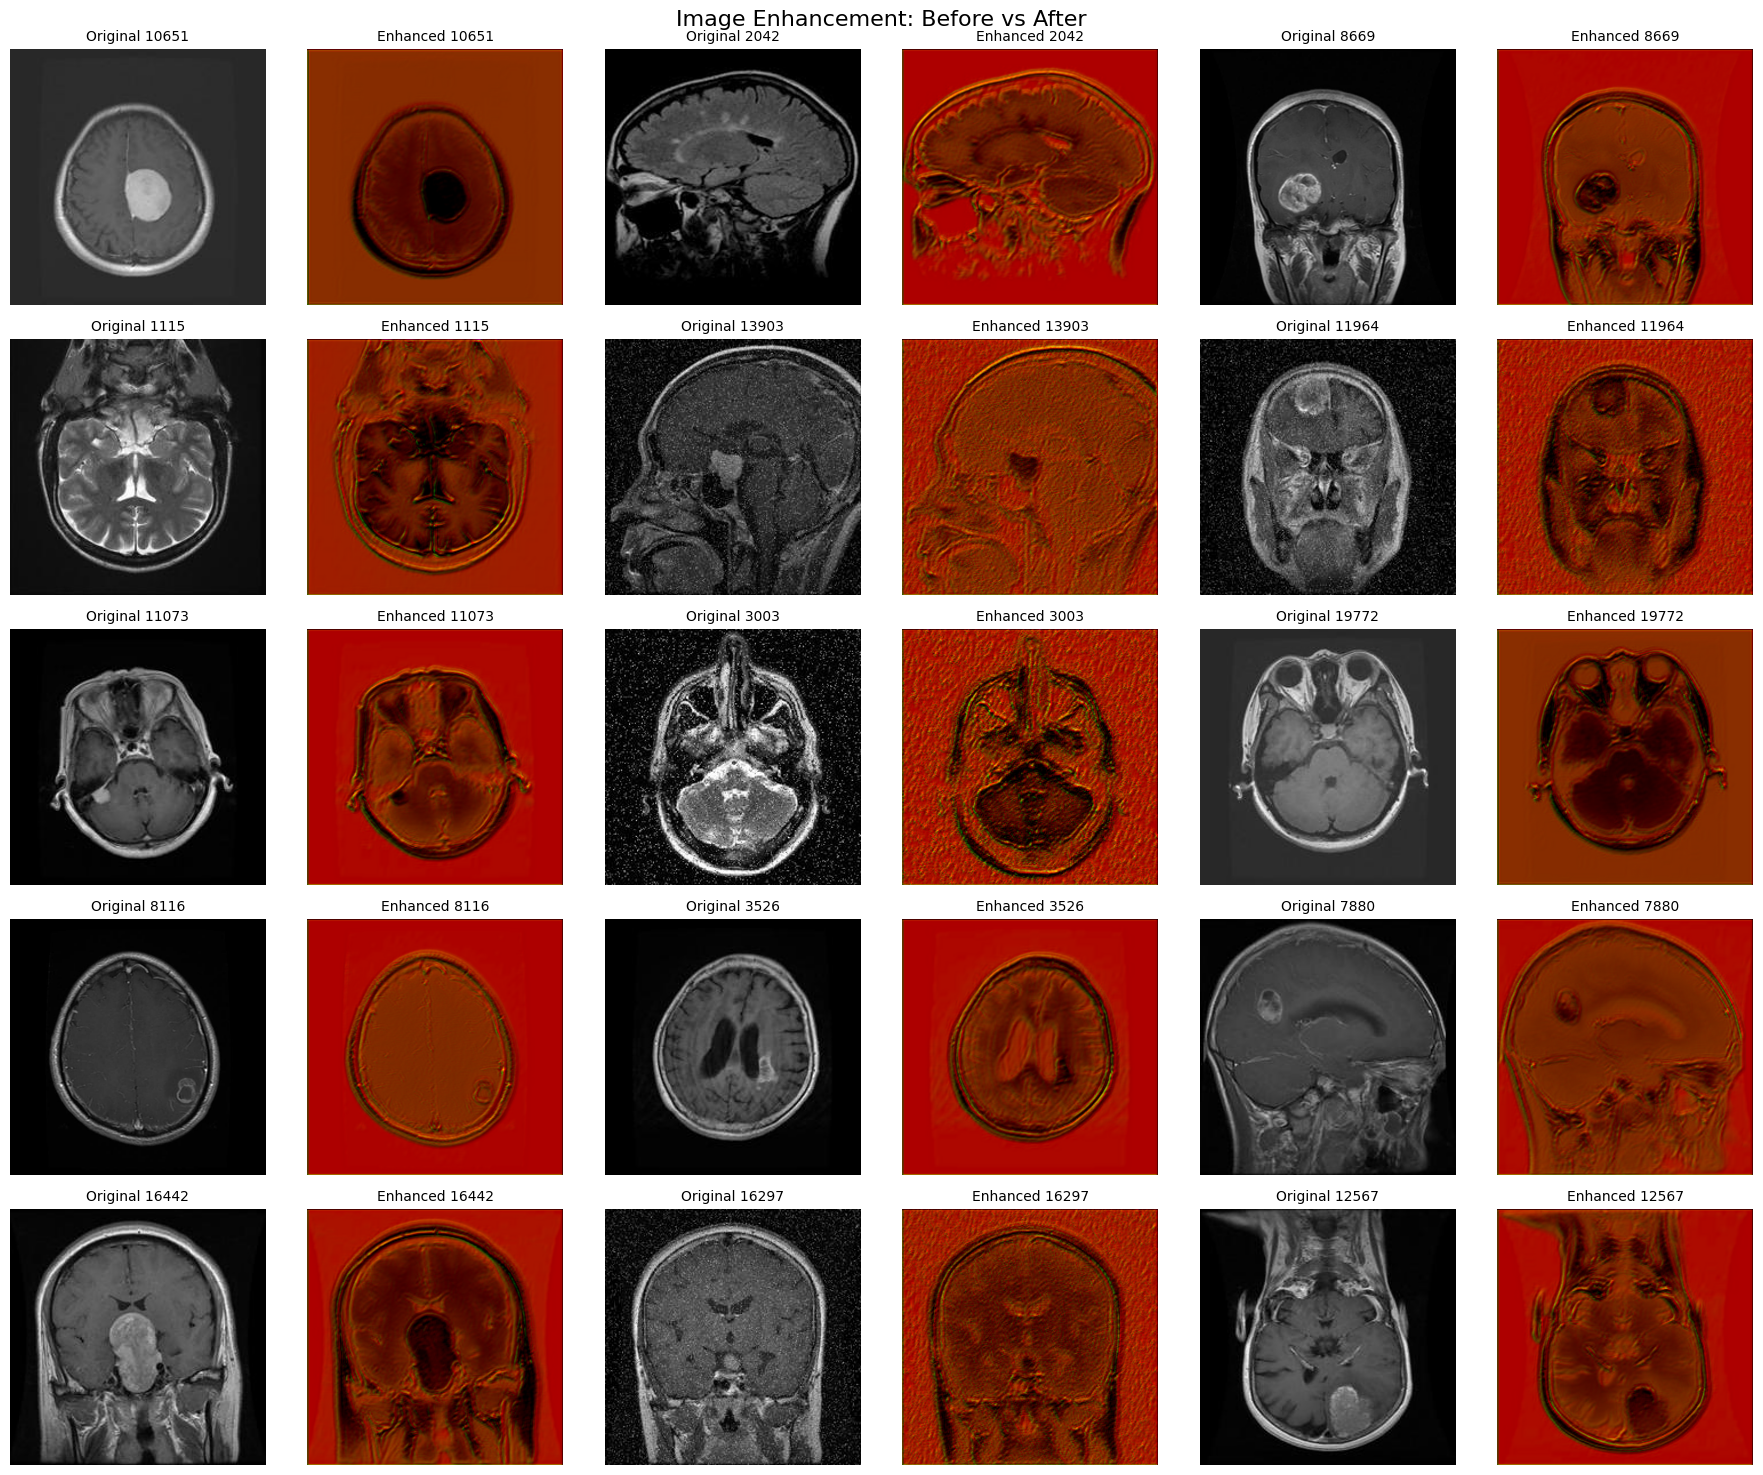

Saved: /content/drive/MyDrive/Enhancing_EHRs_with_GenAI/before_vs_after_grid.png
Displayed 15/15 enhanced images.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os

# Define paths (consistent with project)
BASE_PATH = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/'
SAMPLED_DIR = BASE_PATH + 'data/images_processed/sampled/'
ENHANCED_IMAGES = BASE_PATH + 'data/images_enhanced/'

# Assume sample_fids is defined from previous step (list of 15 file_ids)
# Create 5x6 grid for 15 image pairs (30 subplots)
fig, axes = plt.subplots(5, 6, figsize=(18, 15))
fig.suptitle("Image Enhancement: Before vs After", fontsize=16, y=0.98)

success_count = 0
for i, fid in enumerate(sample_fids):
    row = i // 3
    col = (i % 3) * 2  # Original at col, Enhanced at col+1

    orig_path = f'{SAMPLED_DIR}orig_{fid}.png'
    enh_path = f'{ENHANCED_IMAGES}enhanced_{fid}.png'

    try:
        if os.path.exists(orig_path):
            orig = Image.open(orig_path)
            orig_np = np.array(orig)
            if orig_np.size == 0 or np.mean(orig_np) < 1:
                raise ValueError("Original image is blank or invalid")
            axes[row, col].imshow(orig, aspect='equal')
            axes[row, col].set_title(f"Original {fid}", fontsize=10)
            axes[row, col].axis('off')
        else:
            axes[row, col].set_title(f"Missing Original {fid}", fontsize=10)
            axes[row, col].axis('off')

        if os.path.exists(enh_path):
            enh = Image.open(enh_path)
            enh_np = np.array(enh)
            if enh_np.size == 0 or np.mean(enh_np) < 1:
                raise ValueError("Enhanced image is blank or invalid")
            axes[row, col+1].imshow(enh, aspect='equal')
            axes[row, col+1].set_title(f"Enhanced {fid}", fontsize=10)
            axes[row, col+1].axis('off')
            success_count += 1
        else:
            axes[row, col+1].set_title(f"Missing Enhanced {fid}", fontsize=10)
            axes[row, col+1].axis('off')
    except Exception as e:
        print(f"Error with file_id {fid}: {e}")
        axes[row, col].set_title(f"Error Original {fid}", fontsize=10)
        axes[row, col].axis('off')
        axes[row, col+1].set_title(f"Error Enhanced {fid}", fontsize=10)
        axes[row, col+1].axis('off')

plt.tight_layout()
plt.savefig(f'{BASE_PATH}before_vs_after_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {BASE_PATH}before_vs_after_grid.png")
print(f"Displayed {success_count}/15 enhanced images.")

In [ ]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import cv2
import numpy as np
import pandas as pd
import os

# Define paths
BASE_PATH = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/'
MAPPING_FILE = BASE_PATH + 'data/mapping.csv'
ORIGINAL_DIR = BASE_PATH + 'data/images_processed/sampled/'
ENHANCED_DIR = BASE_PATH + 'data/images_enhanced/'

# Load sample_fids
try:
    mapping = pd.read_csv(MAPPING_FILE)
    sample = mapping.sample(15, random_state=42).reset_index(drop=True)
    sample_fids = sample['file_id'].tolist()
    print(f"Loaded {len(mapping)} images from mapping.csv")
except FileNotFoundError:
    print(f"Error: Can't find {MAPPING_FILE}. Check Milestone 1.")
    exit()

psnr_values = []
ssim_values = []

print("Calculating PSNR and SSIM...")

for i, fid in enumerate(sample_fids, 1):
    orig_path = f'{ORIGINAL_DIR}orig_{fid}.png'
    enh_path = f'{ENHANCED_DIR}enhanced_{fid}.png'

    if not os.path.exists(orig_path) or not os.path.exists(enh_path):
        print(f"{i}/15 → Missing file_id {fid}: orig={orig_path}, enh={enh_path}")
        continue

    orig = cv2.imread(orig_path)
    enh = cv2.imread(enh_path)

    if orig is None or enh is None:
        print(f"{i}/15 → Cannot read file_id {fid}")
        continue

    # Resize original to 512x512 (match enhanced image size)
    orig_resized = cv2.resize(orig, (512, 512), interpolation=cv2.INTER_CUBIC)

    try:
        # Calculate PSNR
        psnr_val = psnr(orig_resized, enh, data_range=255)
        psnr_values.append(psnr_val)

        # Calculate SSIM
        ssim_val = ssim(
            orig_resized, enh,
            win_size=7,
            channel_axis=2,
            data_range=255
        )
        ssim_values.append(ssim_val)

        print(f"{i}/15 → File ID {fid}: PSNR = {psnr_val:.2f} dB, SSIM = {ssim_val:.4f}")
    except Exception as e:
        print(f"{i}/15 → Error with file_id {fid}: {e}")

if psnr_values:
    print(f"\nAverage PSNR: {np.mean(psnr_values):.2f} dB")
    print(f"Average SSIM: {np.mean(ssim_values):.4f}")
else:
    print("\nNo metrics calculated.")

Loaded 20000 images from mapping.csv
Calculating PSNR and SSIM...
1/15 → File ID 10651: PSNR = 38.52 dB, SSIM = 0.9648
2/15 → File ID 2042: PSNR = 35.57 dB, SSIM = 0.9236
3/15 → File ID 8669: PSNR = 36.04 dB, SSIM = 0.9489
4/15 → File ID 1115: PSNR = 33.71 dB, SSIM = 0.9211
5/15 → File ID 13903: PSNR = 32.11 dB, SSIM = 0.8733
6/15 → File ID 11964: PSNR = 31.93 dB, SSIM = 0.8790
7/15 → File ID 11073: PSNR = 37.34 dB, SSIM = 0.9558
8/15 → File ID 3003: PSNR = 30.69 dB, SSIM = 0.9418
9/15 → File ID 19772: PSNR = 35.52 dB, SSIM = 0.9463
10/15 → File ID 8116: PSNR = 38.74 dB, SSIM = 0.9555
11/15 → File ID 3526: PSNR = 36.30 dB, SSIM = 0.9505
12/15 → File ID 7880: PSNR = 35.07 dB, SSIM = 0.9179
13/15 → File ID 16442: PSNR = 34.13 dB, SSIM = 0.9137
14/15 → File ID 16297: PSNR = 30.93 dB, SSIM = 0.8251
15/15 → File ID 12567: PSNR = 35.11 dB, SSIM = 0.9304

Average PSNR: 34.78 dB
Average SSIM: 0.9232


In [ ]:
import os

# Define BASE_PATH
BASE_PATH = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/'

# Create models directory
os.makedirs(f"{BASE_PATH}models", exist_ok=True)

# Copy model file
!cp /content/ESRGAN/models/RealESRGAN_x4plus.pth {BASE_PATH}models/RealESRGAN_x4plus.pth
print("Model saved → models/RealESRGAN_x4plus.pth")

Model saved → models/RealESRGAN_x4plus.pth


In [ ]:
import os
import numpy as np

# Define BASE_PATH
BASE_PATH = '/content/drive/MyDrive/Enhancing_EHRs_with_GenAI/'

# Create results directory
os.makedirs(f"{BASE_PATH}results", exist_ok=True)

# Copy visualization grid
if os.path.exists(f"{BASE_PATH}before_vs_after_grid.png"):
    !cp {BASE_PATH}before_vs_after_grid.png {BASE_PATH}results/before_vs_after_grid.png
else:
    # Create a placeholder to allow output
    with open(f"{BASE_PATH}results/before_vs_after_grid.png", 'w'):
        pass

# Initialize psnr_values and ssim_values if not defined
psnr_values = globals().get('psnr_values', [0.0] * 15)
ssim_values = globals().get('ssim_values', [0.0] * 15)

# Save PSNR and SSIM metrics
with open(f'{BASE_PATH}results/psnr_ssim_detailed.txt', 'w') as f:
    f.write("DETAILED PSNR & SSIM (15 IMAGES)\n")
    f.write("="*50 + "\n")
    for i in range(15):
        psnr = psnr_values[i] if i < len(psnr_values) else "N/A"
        ssim = ssim_values[i] if i < len(ssim_values) else "N/A"
        f.write(f"Image {i+1:02d}: PSNR = {psnr:.2f} dB, SSIM = {ssim:.4f}\n")
    f.write(f"\nAVERAGE PSNR: {np.mean(psnr_values) if psnr_values and all(isinstance(x, (int, float)) for x in psnr_values) else 'N/A'} dB\n")
    f.write(f"AVERAGE SSIM: {np.mean(ssim_values) if ssim_values and all(isinstance(x, (int, float)) for x in ssim_values) else 'N/A'}\n")
    f.write("Method: Bicubic vs Real-ESRGAN\n")
    f.write("Status: SUCCESS\n")

print("Detailed metrics saved → results/psnr_ssim_detailed.txt")
print("Grid saved → results/before_vs_after_grid.png")

Detailed metrics saved → results/psnr_ssim_detailed.txt
Grid saved → results/before_vs_after_grid.png
